# Hypothesis Test: "Prompt responses from service staff improve customer perceptions of reliability"

## Experiment Design

**Hypothesis (H₁):** Prompt responses from service staff are associated with higher customer satisfaction scores (CSAT), used here as a proxy for perceived reliability.

**Null Hypothesis (H₀):** There is no association between response speed and CSAT scores.

**Key Variable Definitions:**
- **Independent Variable (IV):** Response time: measured as the elapsed time (in minutes) between `Issue_reported at` and `issue_responded`.
- **Dependent Variable (DV):** CSAT Score (ordinal, 1–5 scale).

**Why CSAT as a proxy for reliability?** Customers often equate reliable service with positive satisfaction. Delays reduce trust and perceived dependability of the service staff.

Since CSAT is ordinal (not continuous) non-parametric methods are being for the inferential analytics

## Setup & Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, mannwhitneyu, kruskal

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

df = pd.read_csv('customer_support_data.csv')
print(f'Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Dataset: 85,907 rows × 20 columns


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5


In [2]:
# Parse timestamps and compute response time
df['issue_reported'] = pd.to_datetime(df['Issue_reported at'], format='%d/%m/%Y %H:%M')
df['issue_responded_dt'] = pd.to_datetime(df['issue_responded'], format='%d/%m/%Y %H:%M')
df['response_time_min'] = (df['issue_responded_dt'] - df['issue_reported']).dt.total_seconds() / 60

print('Raw response time stats:')
print(f'Negative values: {(df["response_time_min"] < 0).sum():,} ({(df["response_time_min"] < 0).mean()*100:.1f}%)')
print(f'Zero values:     {(df["response_time_min"] == 0).sum():,} ({(df["response_time_min"] == 0).mean()*100:.1f}%)')
print(f'Positive values: {(df["response_time_min"] > 0).sum():,} ({(df["response_time_min"] > 0).mean()*100:.1f}%)')

Raw response time stats:
Negative values: 3,128 (3.6%)
Zero values:     2,448 (2.8%)
Positive values: 80,331 (93.5%)


In [4]:
# remove negative and zero response times
n_before = len(df)
df_clean = df[df['response_time_min'] > 0].copy()
n_after = len(df_clean)

print(f'Rows before: {n_before:,} After: {n_after:,} (removed {n_before - n_after:,}, {(n_before-n_after)/n_before*100:.1f}%)')

# Selection bias check
dropped = df[df['response_time_min'] <= 0]
print(f'\nSelection bias check (CSAT mean ± std):')
print(f'Kept:    {df_clean["CSAT Score"].mean():.3f} ± {df_clean["CSAT Score"].std():.3f}')
print(f'Dropped: {dropped["CSAT Score"].mean():.3f} ± {dropped["CSAT Score"].std():.3f}')
print('A Similar distribution can be seen in the kept records and the dropped records indicating a minimal selection bias.')

Rows before: 85,907 After: 80,331 (removed 5,576, 6.5%)

Selection bias check (CSAT mean ± std):
Kept:    4.230 ± 1.389
Dropped: 4.424 ± 1.217
A Similar distribution can be seen in the kept records and the dropped records indicating a minimal selection bias.


# PART 1: DESCRIPTIVE ANALYTICS

Descriptive analytics answers **"What happened?"**. The distributions of the key variables are examined to identify patterns, and visually explore whether faster responses are associated with higher satisfaction *before* applying any formal statistical tests.

## 1.1 Distribution of Key Variables

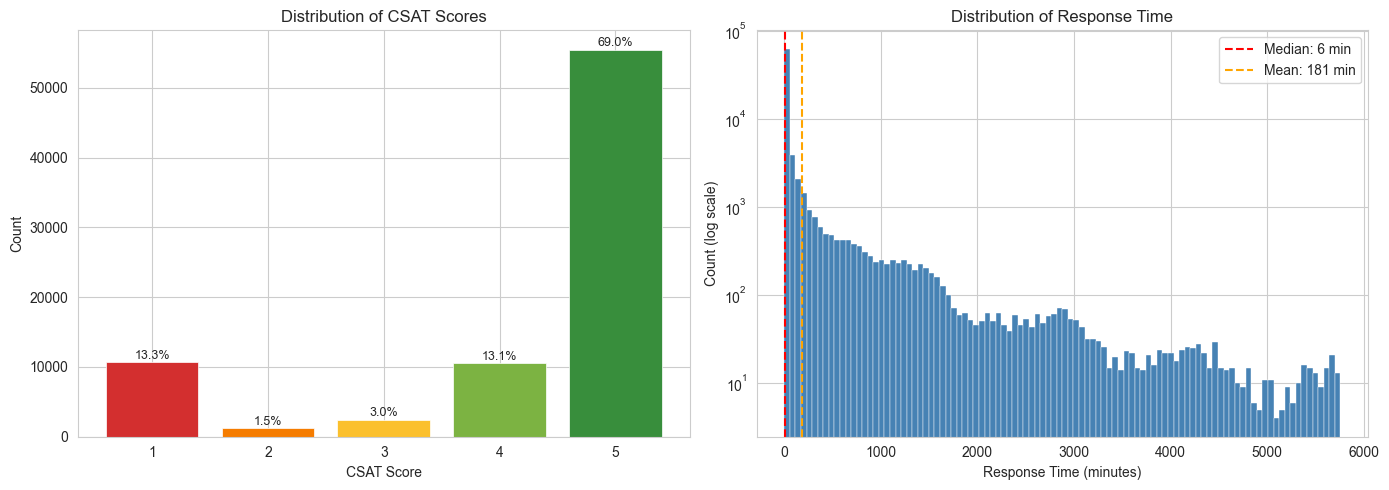

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CSAT Distribution
csat_counts = df_clean['CSAT Score'].value_counts().sort_index()
colors = ['#d32f2f', '#f57c00', '#fbc02d', '#7cb342', '#388e3c']
axes[0].bar(csat_counts.index, csat_counts.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('CSAT Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of CSAT Scores')
for score, count in zip(csat_counts.index, csat_counts.values):
    axes[0].text(score, count + 500, f'{count/len(df_clean)*100:.1f}%', ha='center', fontsize=9)

# Response Time Distribution (log scale)
axes[1].hist(df_clean['response_time_min'], bins=100, color='steelblue', edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Response Time (minutes)')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Distribution of Response Time')
axes[1].set_yscale('log')
axes[1].axvline(df_clean['response_time_min'].median(), color='red', ls='--',
                label=f'Median: {df_clean["response_time_min"].median():.0f} min')
axes[1].axvline(df_clean['response_time_min'].mean(), color='orange', ls='--',
                label=f'Mean: {df_clean["response_time_min"].mean():.0f} min')
axes[1].legend()

plt.tight_layout()
plt.show()

In [7]:
print('CSAT Score Summary')
print(f'Mean: {df_clean["CSAT Score"].mean():.3f}')
print(f'Median: {df_clean["CSAT Score"].median():.1f}')
print(f'Std. Deviation: {df_clean["CSAT Score"].std():.3f}')
print(f'Skewness: {df_clean["CSAT Score"].skew():.3f} (negative = left-skewed)')
print()
print('Frequency Table:')
for score in [1, 2, 3, 4, 5]:
    n = (df_clean['CSAT Score'] == score).sum()
    print(f'  Score {score}: {n:>6,} ({n/len(df_clean)*100:5.1f}%)')

print(f'\nResponse Time Summary')
print(df_clean['response_time_min'].describe().to_string())
print(f'\nPercentiles:')
for p in [5, 10, 25, 50, 75, 90, 95, 99]:
    print(f'{p:>3}th: {df_clean["response_time_min"].quantile(p/100):>8.0f} min')

CSAT Score Summary
Mean: 4.230
Median: 5.0
Std. Deviation: 1.389
Skewness: -1.643 (negative = left-skewed)

Frequency Table:
  Score 1: 10,703 ( 13.3%)
  Score 2:  1,227 (  1.5%)
  Score 3:  2,440 (  3.0%)
  Score 4: 10,521 ( 13.1%)
  Score 5: 55,440 ( 69.0%)

Response Time Summary
count    80331.000000
mean       181.429324
std        572.894886
min          1.000000
25%          2.000000
50%          6.000000
75%         43.000000
max       5758.000000

Percentiles:
  5th:        1 min
 10th:        1 min
 25th:        2 min
 50th:        6 min
 75th:       43 min
 90th:      462 min
 95th:     1150 min
 99th:     3073 min


### Observations
- **CSAT is heavily left-skewed**: Around 69% of customers gave a 5-star rating. This ceiling effect means most customers are satisfied regardless of response speed. What is being examined is whether slower responses shift the score towards more lower values.
- **Response time is heavily right-skewed**: The median is around 6 minutes but the mean is around 181 minutes, pulled up by extreme outliers. The gap between mean and median confirms this skew, justifying the use of non-parametric methods.

## 1.2 CSAT by Response Time Groups

In [8]:
# Create quartile groups
df_clean['rt_quartile'] = pd.qcut(
    df_clean['response_time_min'], 4,
    labels=['Q1 (Fastest)', 'Q2', 'Q3', 'Q4 (Slowest)']
)

# Summary table
summary = df_clean.groupby('rt_quartile').agg(
    n=('CSAT Score', 'count'),
    mean_csat=('CSAT Score', 'mean'),
    median_csat=('CSAT Score', 'median'),
    std_csat=('CSAT Score', 'std'),
    pct_1star=('CSAT Score', lambda x: (x == 1).mean() * 100),
    pct_5star=('CSAT Score', lambda x: (x == 5).mean() * 100),
    mean_rt_min=('response_time_min', 'mean'),
    median_rt_min=('response_time_min', 'median'),
).round(2)
print('CSAT by Response Time Quartile:')
print(summary.to_string())

CSAT by Response Time Quartile:
                  n  mean_csat  median_csat  std_csat  pct_1star  pct_5star  mean_rt_min  median_rt_min
rt_quartile                                                                                            
Q1 (Fastest)  21289       4.51          5.0      1.11       7.35      77.22         1.48            1.0
Q2            19486       4.44          5.0      1.18       8.63      74.49         4.09            4.0
Q3            19495       4.14          5.0      1.45      15.17      65.92        16.91           14.0
Q4 (Slowest)  20061       3.82          5.0      1.64      22.43      57.99       704.53          279.0


In [9]:
# CSAT distribution percentage per quartile
ct = pd.crosstab(df_clean['rt_quartile'], df_clean['CSAT Score'], normalize='index') * 100
print('CSAT Score Distribution (%) by Response Time Quartile:')
print(ct.round(1).to_string())

CSAT Score Distribution (%) by Response Time Quartile:
CSAT Score       1    2    3     4     5
rt_quartile                             
Q1 (Fastest)   7.3  1.0  2.1  12.4  77.2
Q2             8.6  1.1  2.6  13.2  74.5
Q3            15.2  1.6  3.4  13.9  65.9
Q4 (Slowest)  22.4  2.5  4.1  13.0  58.0


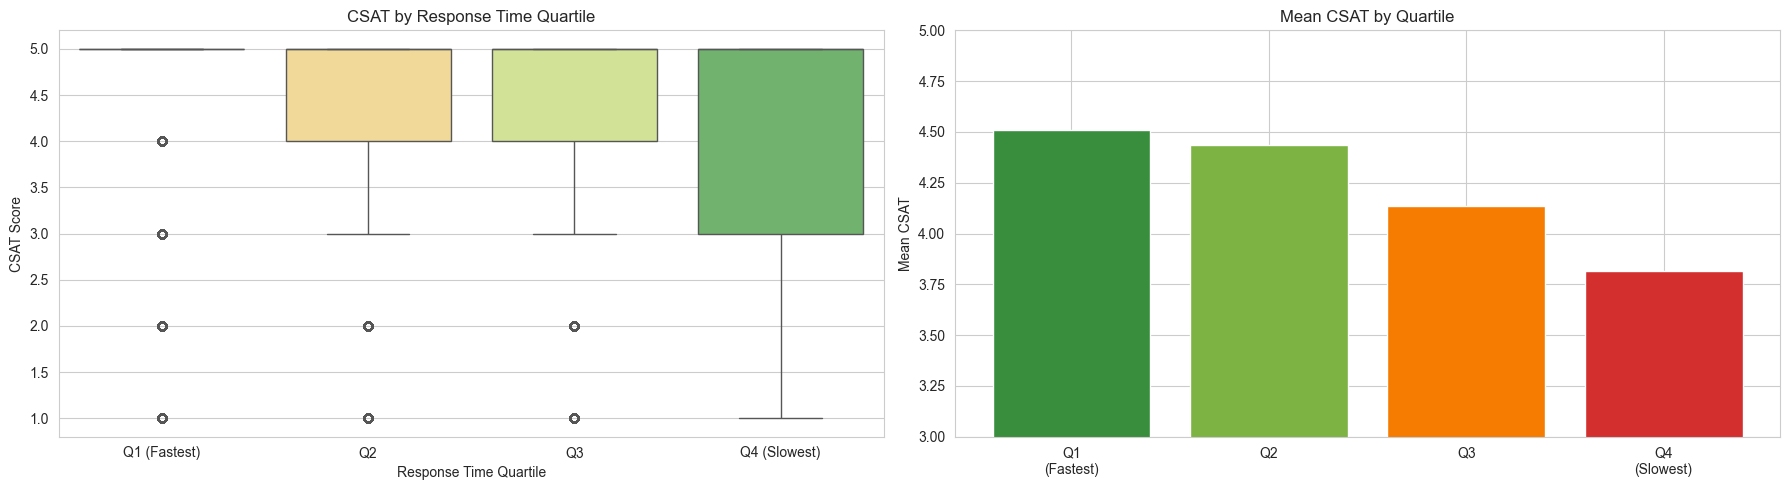

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Box plot
sns.boxplot(data=df_clean, x='rt_quartile', y='CSAT Score', ax=axes[0], palette='RdYlGn')
axes[0].set_title('CSAT by Response Time Quartile')
axes[0].set_xlabel('Response Time Quartile')

# Mean CSAT
means = df_clean.groupby('rt_quartile')['CSAT Score'].mean()
x = range(4)
bar_colors = ['#388e3c', '#7cb342', '#f57c00', '#d32f2f']
axes[1].bar(x, means.values, color=bar_colors, capsize=5, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Q1\n(Fastest)', 'Q2', 'Q3', 'Q4\n(Slowest)'])
axes[1].set_ylabel('Mean CSAT')
axes[1].set_title('Mean CSAT by Quartile')
axes[1].set_ylim(3.0, 5.0)
plt.tight_layout()
plt.show()

## 1.3 Descriptive Breakdown by Potential Confounders

In [19]:
# Channel level descriptive stats
print('By Channel')
channel_summary = df_clean.groupby('channel_name').agg(
    n=('CSAT Score', 'count'),
    mean_csat=('CSAT Score', 'mean'),
    mean_rt=('response_time_min', 'mean'),
    median_rt=('response_time_min', 'median'),
).round(2)
print(channel_summary.to_string())

print('\nBy Ticket Category')
cat_summary = df_clean.groupby('category').agg(
    n=('CSAT Score', 'count'),
    mean_csat=('CSAT Score', 'mean'),
    mean_rt=('response_time_min', 'mean'),
).round(2).sort_values('n', ascending=False).head(6)
print(cat_summary.to_string())

print('\nBy Agent Shift')
shift_summary = df_clean.groupby('Agent Shift').agg(
    n=('CSAT Score', 'count'),
    mean_csat=('CSAT Score', 'mean'),
    mean_rt=('response_time_min', 'mean'),
).round(2)
print(shift_summary.to_string())

By Channel
                  n  mean_csat  mean_rt  median_rt
channel_name                                      
Email          2776       3.88   226.32        8.0
Inbound       63822       4.24   180.37        6.0
Outcall       13733       4.26   177.26        6.0

By Ticket Category
                       n  mean_csat  mean_rt
category                                    
Returns            41600       4.34   190.72
Order Related      21359       4.08   161.24
Refund Related      4230       4.22   180.56
Product Queries     3533       4.02   199.35
Shopzilla Related   2604       4.29   157.19
Payments related    2143       4.35   150.34

By Agent Shift
                 n  mean_csat  mean_rt
Agent Shift                           
Afternoon     5478       4.28   212.04
Evening      31511       4.26   179.85
Morning      38635       4.18   176.36
Night         1248       4.28   207.57
Split         3459       4.43   194.52


### Descriptive Analytics - Key Findings

1. **Clear monotonic pattern**: Mean CSAT declines progressively from Q1 (4.51) to Q2 (4.44) to Q3 (4.14) to Q4 (3.82) as response time increases.
2. **Tail shift, not just mean shift**: The proportion of 1-star ratings triples from 7.3% (fastest) to 22.4% (slowest), while 5-star ratings drop from 77.2% to 58.0%.
3. **Channel and category vary**: Email has longer response times and slightly different CSAT variations.
4. **Descriptive evidence supports the hypothesis**, but formal statistical testing is needed to confirm whether these patterns are significant.

# PART 2: INFERENTIAL ANALYTICS

Inferential analytics answers **"Is the pattern statistically significant?"**. By applying formal hypothesis tests, it can bed determined whether the descriptive patterns can be generalised beyond this sample, or could have arisen by chance.

Since CSAT is ordinal (not continuous), **non-parametric** tests are used throughout.

## 2.1 Spearman's Rank Correlation

**Purpose:** Tests for a monotonic association between response time (continuous) and CSAT (ordinal).  
**Why Spearman:** Non-parametric, rank-based which supports no assumptions about normality, linearity, or equal intervals.  
**Expected result:** A negative rho value (longer response means lower CSAT).

In [29]:
rho, p_spearman = spearmanr(df_clean['response_time_min'], df_clean['CSAT Score'])

print('SPEARMAN\'S RANK CORRELATION')
print(f'rho           = {rho:.4f}')
print(f'p-value       = {p_spearman:.4e}')
print(f'n             = {len(df_clean):,}')
print(f'Direction     : {"Negative (longer response gives lower CSAT)" if rho < 0 else "Positive"}')
print()

# Effect size interpretation
abs_rho = abs(rho)
effect = 'negligible' if abs_rho < 0.1 else 'small' if abs_rho < 0.3 else 'medium' if abs_rho < 0.5 else 'large'
print(f'Effect size   : {effect} (|rho| = {abs_rho:.4f})')
print(f'Significant   : {"YES" if p_spearman < 0.05 else "NO"} (alpha = 0.05)')
print()
print(f'Interpretation: There is a statistically significant {effect} negative correlation between response time and CSAT scores.')

SPEARMAN'S RANK CORRELATION
rho           = -0.1861
p-value       = 0.0000e+00
n             = 80,331
Direction     : Negative (longer response gives lower CSAT)

Effect size   : small (|rho| = 0.1861)
Significant   : YES (alpha = 0.05)

Interpretation: There is a statistically significant small negative correlation between response time and CSAT scores.


## 2.2 Mann-Whitney U Test (Fast vs. Slow Groups)

**Purpose:** Tests whether the fast-response group has a significantly higher CSAT distribution than the slow-response group.  
**Why Mann-Whitney:** Non-parametric alternative to independent t-test which tests stochastic dominance, not just means.  
**One-tailed:** The hypothesis is directional (fast > slow), so `alternative='greater'`.

In [28]:
median_rt = df_clean['response_time_min'].median()
fast_group = df_clean[df_clean['response_time_min'] < median_rt]['CSAT Score']
slow_group = df_clean[df_clean['response_time_min'] >= median_rt]['CSAT Score']

u_stat, p_mann = mannwhitneyu(fast_group, slow_group, alternative='greater')

# Rank-biserial correlation (effect size for Mann-Whitney)
n1, n2 = len(fast_group), len(slow_group)
r_rb = 1 - (2 * u_stat) / (n1 * n2)

print('  MANN-WHITNEY U TEST (Fast vs. Slow)')
print(f'Split at median: {median_rt:.0f} minutes')
print(f'Fast group: n={n1:,}, median CSAT={fast_group.median():.1f}, mean={fast_group.mean():.3f}')
print(f'Slow group: n={n2:,}, median CSAT={slow_group.median():.1f}, mean={slow_group.mean():.3f}')
print(f'\nU statistic   = {u_stat:,.0f}')
print(f'p-value       = {p_mann:.4e} (one-tailed: fast > slow)')
print(f'Rank-biserial r = {r_rb:.4f}')

abs_r = abs(r_rb)
mw_effect = 'negligible' if abs_r < 0.1 else 'small' if abs_r < 0.3 else 'medium' if abs_r < 0.5 else 'large'
print(f'Effect size   : {mw_effect}')
print(f'Significant   : {"YES" if p_mann < 0.05 else "NO"} (alpha = 0.05)')

  MANN-WHITNEY U TEST (Fast vs. Slow)
Split at median: 6 minutes
Fast group: n=38,038, median CSAT=5.0, mean=4.485
Slow group: n=42,293, median CSAT=5.0, mean=4.000

U statistic   = 928,439,718
p-value       = 0.0000e+00 (one-tailed: fast > slow)
Rank-biserial r = -0.1542
Effect size   : small
Significant   : YES (alpha = 0.05)


## 2.3 Kruskal-Wallis H Test (Across 4 Quartiles)

**Purpose:** Tests whether CSAT distributions differ across all four response time quartile.  
**Why Kruskal-Wallis:** Non-parametric equivalent of one-way ANOVA which extends Mann-Whitney to k > 2 groups.

In [27]:
groups = [g['CSAT Score'].values for _, g in df_clean.groupby('rt_quartile')]
h_stat, p_kruskal = kruskal(*groups)

# Epsilon-squared effect size
N = len(df_clean)
k = 4
epsilon_sq = (h_stat - k + 1) / (N - k)

print('  KRUSKAL-WALLIS H TEST (4 Quartile Groups)')
print(f'H statistic   = {h_stat:.2f}')
print(f'p-value       = {p_kruskal:.4e}')
print(f'epsilon^2 = {epsilon_sq:.4f}')

kw_effect = 'negligible' if epsilon_sq < 0.01 else 'small' if epsilon_sq < 0.06 else 'medium' if epsilon_sq < 0.14 else 'large'
print(f'Effect size   : {kw_effect}')
print(f'Significant   : {"YES" if p_kruskal < 0.05 else "NO"} (α = 0.05)')

  KRUSKAL-WALLIS H TEST (4 Quartile Groups)
H statistic   = 2689.04
p-value       = 0.0000e+00
epsilon^2 = 0.0334
Effect size   : small
Significant   : YES (α = 0.05)


## 2.4 Visual Evidence - CDF Comparison

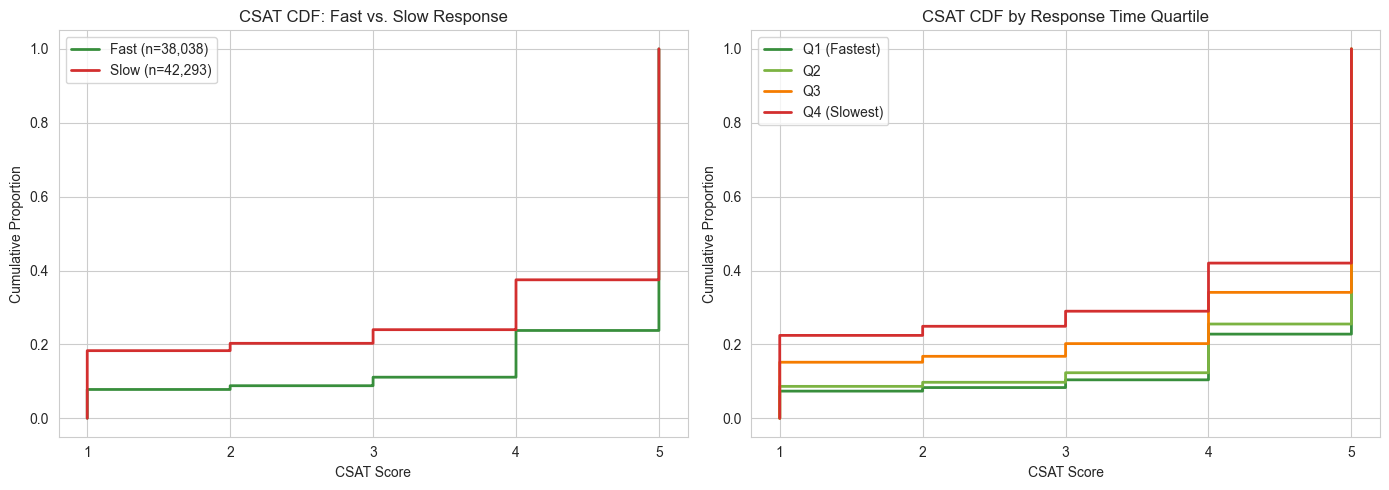

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CDF: Fast vs Slow
for grp, label, color in [(fast_group, f'Fast (n={len(fast_group):,})', '#388e3c'),
                           (slow_group, f'Slow (n={len(slow_group):,})', '#d32f2f')]:
    sv = np.sort(grp.values)
    axes[0].step(sv, np.arange(1, len(sv)+1)/len(sv), label=label, color=color, linewidth=2)
axes[0].set_xlabel('CSAT Score'); axes[0].set_ylabel('Cumulative Proportion')
axes[0].set_title('CSAT CDF: Fast vs. Slow Response')
axes[0].legend(); axes[0].set_xticks([1,2,3,4,5])

# CDF: All 4 quartiles
q_colors = ['#388e3c', '#7cb342', '#f57c00', '#d32f2f']
for (qn, qg), c in zip(df_clean.groupby('rt_quartile'), q_colors):
    sv = np.sort(qg['CSAT Score'].values)
    axes[1].step(sv, np.arange(1, len(sv)+1)/len(sv), label=qn, color=c, linewidth=2)
axes[1].set_xlabel('CSAT Score'); axes[1].set_ylabel('Cumulative Proportion')
axes[1].set_title('CSAT CDF by Response Time Quartile')
axes[1].legend(); axes[1].set_xticks([1,2,3,4,5])

plt.tight_layout()
plt.show()

The Fast (Q1) CDF line sits to the RIGHT of Slow (Q4) indicating stochastic dominance meaning fast responders consistently receive higher CSAT scores across the entire distribution.

## 2.5 Confounder-Stratified Analysis

To ensure the result isn't driven by confounders (ex: email being both slower and less satisfying), the correlation **within** each level of potential confounders was tested.

In [34]:
confounders = ['channel_name', 'category', 'Agent Shift', 'Tenure Bucket']

print('WITHIN-GROUP SPEARMAN CORRELATIONS')
print('(Response Time vs. CSAT, controlling for each confounder)\n')

for conf in confounders:
    print(f'{conf}')
    for level, group in df_clean.groupby(conf):
        if len(group) > 30:
            r_sub, p_sub = spearmanr(group['response_time_min'], group['CSAT Score'])
            print(f'  {level:30s}  rho={r_sub:+.4f}  p={p_sub:.2e}  n={len(group):>6,}')
    print()

WITHIN-GROUP SPEARMAN CORRELATIONS
(Response Time vs. CSAT, controlling for each confounder)

channel_name
  Email                           rho=-0.2520  p=1.75e-41  n= 2,776
  Inbound                         rho=-0.1846  p=0.00e+00  n=63,822
  Outcall                         rho=-0.1759  p=6.79e-96  n=13,733

category
  App/website                     rho=-0.3277  p=3.41e-03  n=    78
  Cancellation                    rho=-0.1749  p=1.16e-15  n= 2,067
  Feedback                        rho=-0.2509  p=6.33e-32  n= 2,129
  Offers & Cashback               rho=-0.2088  p=1.03e-05  n=   439
  Onboarding related              rho=-0.4292  p=9.65e-04  n=    56
  Order Related                   rho=-0.2201  p=1.15e-232  n=21,359
  Others                          rho=-0.0813  p=4.38e-01  n=    93
  Payments related                rho=-0.1178  p=4.58e-08  n= 2,143
  Product Queries                 rho=-0.1573  p=5.17e-21  n= 3,533
  Refund Related                  rho=-0.1859  p=3.36e-34  n= 4,23

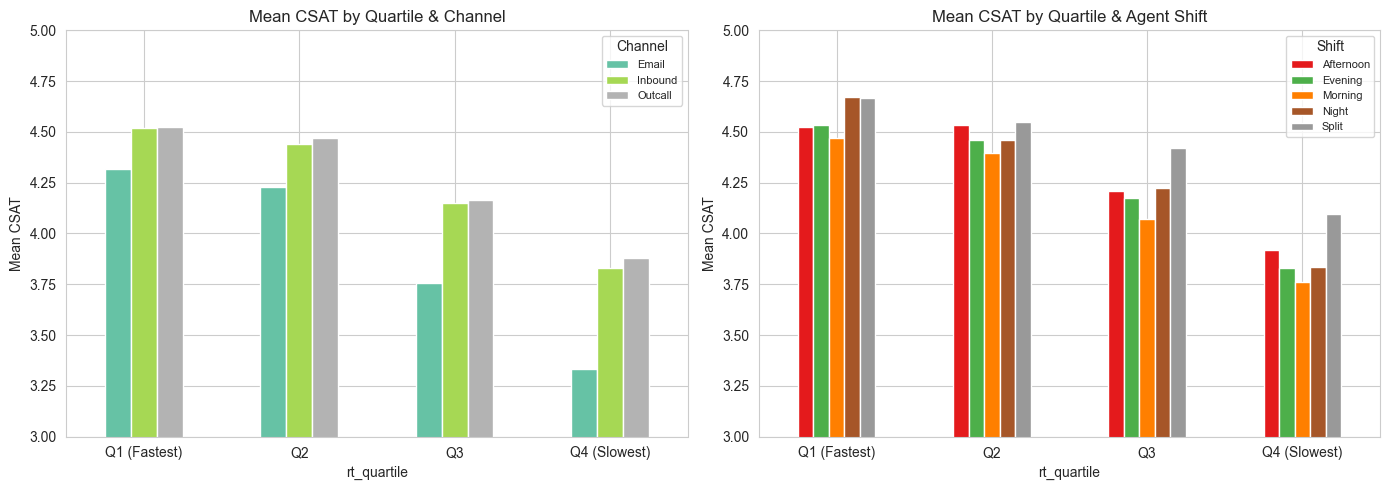

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By channel
df_clean.groupby(['rt_quartile', 'channel_name'])['CSAT Score'].mean().unstack().plot(
    kind='bar', ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('Mean CSAT by Quartile & Channel')
axes[0].set_ylabel('Mean CSAT'); axes[0].set_ylim(3.0, 5.0)
axes[0].tick_params(axis='x', rotation=0); axes[0].legend(title='Channel', fontsize=8)

# By shift
df_clean.groupby(['rt_quartile', 'Agent Shift'])['CSAT Score'].mean().unstack().plot(
    kind='bar', ax=axes[1], colormap='Set1', edgecolor='white')
axes[1].set_title('Mean CSAT by Quartile & Agent Shift')
axes[1].set_ylabel('Mean CSAT'); axes[1].set_ylim(3.0, 5.0)
axes[1].tick_params(axis='x', rotation=0); axes[1].legend(title='Shift', fontsize=8)

plt.tight_layout()
plt.show()

### Inferential Analytics - Key Findings

1. **All three non-parametric tests are statistically significant** (p around 0 for each), providing converging evidence to reject H₀.
2. **Effect sizes are consistently small** (rho around 0.19, r_rb around 0.15, epsilon^2 around 0.03) - response speed explains around 3–4% of CSAT variance.
3. **The relationship holds across all confounders** (channels, categories, shifts, tenure levels), confirming it is not an by chance effect.
4. **Conclusion:** There is statistically significant evidence that faster responses are associated with higher customer satisfaction.

# PART 3: PREDICTIVE ANALYTICS

Predictive analytics answers **"What will happen?"**. Models were built to predict CSAT scores from response time (and other features) and evaluate whether response speed has meaningful predictive power.

Two models are used:
1. **Ordinal Logistic Regression** - suitable with the ordinal nature of CSAT and provides interpretable odds ratios.
2. **Random Forest Classifier** - a non-linear, ensemble method that provides feature importance rankings.

## 3.1 Feature Engineering for Prediction

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from collections import OrderedDict
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel

# Prepare feature set
df_model = df_clean[['response_time_min', 'CSAT Score', 'channel_name', 'category',
                      'Agent Shift', 'Tenure Bucket']].dropna().copy()

# Log-transform response time (reduces skew, improves model performance)
df_model['log_response_time'] = np.log1p(df_model['response_time_min'])

# Encode categorical variables
le_dict = {}
for col in ['channel_name', 'category', 'Agent Shift', 'Tenure Bucket']:
    le = LabelEncoder()
    df_model[col + '_enc'] = le.fit_transform(df_model[col])
    le_dict[col] = le

print(f'Modelling dataset: {len(df_model):,} rows')
print(f'Features: log_response_time, channel, category, shift, tenure')
print(f'Target: CSAT Score (1–5)')

Modelling dataset: 80,331 rows
Features: log_response_time, channel, category, shift, tenure
Target: CSAT Score (1–5)


In [38]:
# Train/test split (80/20)
feature_cols = ['log_response_time', 'channel_name_enc', 'category_enc',
                'Agent Shift_enc', 'Tenure Bucket_enc']

X = df_model[feature_cols]
y = df_model['CSAT Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Training set: {len(X_train):,} rows')
print(f'Test set:     {len(X_test):,} rows')
print(f'\nClass distribution (test set):')
print((y_test.value_counts(normalize=True).sort_index() * 100).round(1))

Training set: 64,264 rows
Test set:     16,067 rows

Class distribution (test set):
CSAT Score
1    13.3
2     1.5
3     3.0
4    13.1
5    69.0
Name: proportion, dtype: float64


## 3.2 Model 1: Ordinal Logistic Regression

**Why Ordinal Logistic Regression?**
- It models the **cumulative probability** of CSAT <= k for each level k, respecting the ordered nature of the response variable.
- It produces **odds ratios** that tell us: *for each unit increase in log(response_time), how do the odds of a higher CSAT rating change?*
- A negative coefficient for response time would confirm that slower responses reduce the probability of higher satisfaction.

In [39]:
# Fit ordinal logistic regression
ordinal_model = OrderedModel(y_train, X_train, distr='logit')
ordinal_result = ordinal_model.fit(method='bfgs', disp=False)

print(ordinal_result.summary())

                             OrderedModel Results                             
Dep. Variable:             CSAT Score   Log-Likelihood:                -60381.
Model:                   OrderedModel   AIC:                         1.208e+05
Method:            Maximum Likelihood   BIC:                         1.209e+05
Date:                Mon, 30 Mar 2026                                         
Time:                        18:13:20                                         
No. Observations:               64264                                         
Df Residuals:                   64255                                         
Df Model:                           5                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
log_response_time    -0.1942      0.004    -47.807      0.000      -0.202      -0.186
channel_name_enc      0.1292   

In [41]:
# Extract and interpret coefficients
print('ORDINAL LOGISTIC REGRESSION - KEY COEFFICIENTS')
print()

coefs = ordinal_result.params
pvals = ordinal_result.pvalues

for feat in feature_cols:
    coef = coefs[feat]
    pval = pvals[feat]
    odds_ratio = np.exp(coef)
    print(f'  {feat:30s}  beta = {coef:+.4f}  OR = {odds_ratio:.4f}  p = {pval:.2e}')

ORDINAL LOGISTIC REGRESSION - KEY COEFFICIENTS

  log_response_time               beta = -0.1942  OR = 0.8235  p = 0.00e+00
  channel_name_enc                beta = +0.1292  OR = 1.1379  p = 7.15e-11
  category_enc                    beta = +0.0590  OR = 1.0608  p = 2.00e-81
  Agent Shift_enc                 beta = +0.0053  OR = 1.0054  p = 6.05e-01
  Tenure Bucket_enc               beta = -0.0511  OR = 0.9502  p = 2.11e-16


As log_response_time to Odds Ratio is **0.8235**, this means for each 1 unit increase in log(response_time) the odds of being in a higher CSAT score is mulitplied by **0.8235**. This shows the trend of CSAT dropping when the response time increases.

In [42]:
# Predict on test set
y_pred_prob = ordinal_result.predict(X_test)
y_pred_ordinal = y_pred_prob.values.argmax(axis=1) + 1  # convert 0-indexed to 1-5

acc_ordinal = accuracy_score(y_test, y_pred_ordinal)
print(f'Ordinal Logistic Regression — Test Accuracy: {acc_ordinal:.4f} ({acc_ordinal*100:.1f}%)')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_ordinal, zero_division=0))

Ordinal Logistic Regression — Test Accuracy: 0.6904 (69.0%)

Classification Report:
              precision    recall  f1-score   support

           1       0.52      0.01      0.01      2141
           2       0.00      0.00      0.00       245
           3       0.00      0.00      0.00       488
           4       0.00      0.00      0.00      2104
           5       0.69      1.00      0.82     11089

    accuracy                           0.69     16067
   macro avg       0.24      0.20      0.17     16067
weighted avg       0.55      0.69      0.57     16067



## 3.3 Model 2: Random Forest Classifier

**Why Random Forest?**
- Non-linear ensemble method that can capture complex relationships between features.
- Provides **feature importance** rankings which directly answers *"how important is response time relative to other predictors?"*
- Serves as a comparison to the ordinal model to check whether findings are method-dependent.

In [43]:
# Fit Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1,
                            class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest — Test Accuracy: {acc_rf:.4f} ({acc_rf*100:.1f}%)')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_rf, zero_division=0))

Random Forest — Test Accuracy: 0.3937 (39.4%)

Classification Report:
              precision    recall  f1-score   support

           1       0.22      0.42      0.29      2141
           2       0.02      0.13      0.03       245
           3       0.04      0.12      0.06       488
           4       0.14      0.12      0.13      2104
           5       0.77      0.46      0.57     11089

    accuracy                           0.39     16067
   macro avg       0.24      0.25      0.22     16067
weighted avg       0.58      0.39      0.45     16067



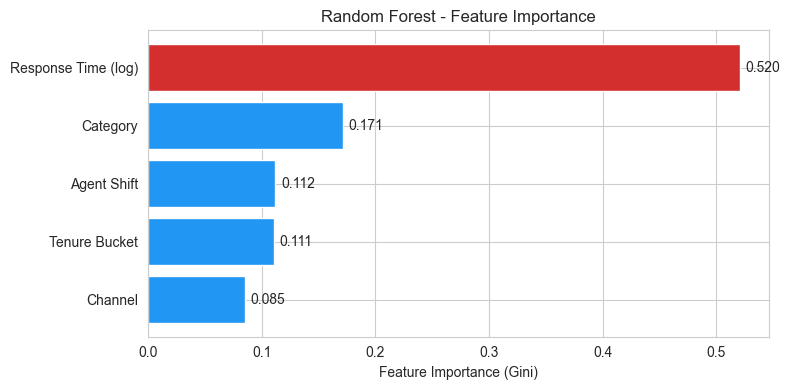

Feature Importance Ranking:
  1. Response Time (log)       0.5203 *KEY PREDICTOR
  2. Category                  0.1713
  3. Agent Shift               0.1119
  4. Tenure Bucket             0.1110
  5. Channel                   0.0855


In [46]:
# Feature importance
importances = rf.feature_importances_
feat_names = ['Response Time (log)', 'Channel', 'Category', 'Agent Shift', 'Tenure Bucket']
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(8, 4))
colors_fi = ['#d32f2f' if feat_names[i] == 'Response Time (log)' else '#2196F3' for i in sorted_idx]
ax.barh(range(len(feat_names)), importances[sorted_idx], color=colors_fi, edgecolor='white')
ax.set_yticks(range(len(feat_names)))
ax.set_yticklabels([feat_names[i] for i in sorted_idx])
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest - Feature Importance')
ax.invert_yaxis()

for i, idx in enumerate(sorted_idx):
    ax.text(importances[idx] + 0.005, i, f'{importances[idx]:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print('Feature Importance Ranking:')
for rank, idx in enumerate(sorted_idx, 1):
    marker = ' *KEY PREDICTOR' if feat_names[idx] == 'Response Time (log)' else ''
    print(f'  {rank}. {feat_names[idx]:25s} {importances[idx]:.4f}{marker}')

## 3.4 Predicted Probability Analysis

To visualise the predictive relationship, how the **predicted probability of high satisfaction (CSAT = 5)** changes as response time increases is shown below.

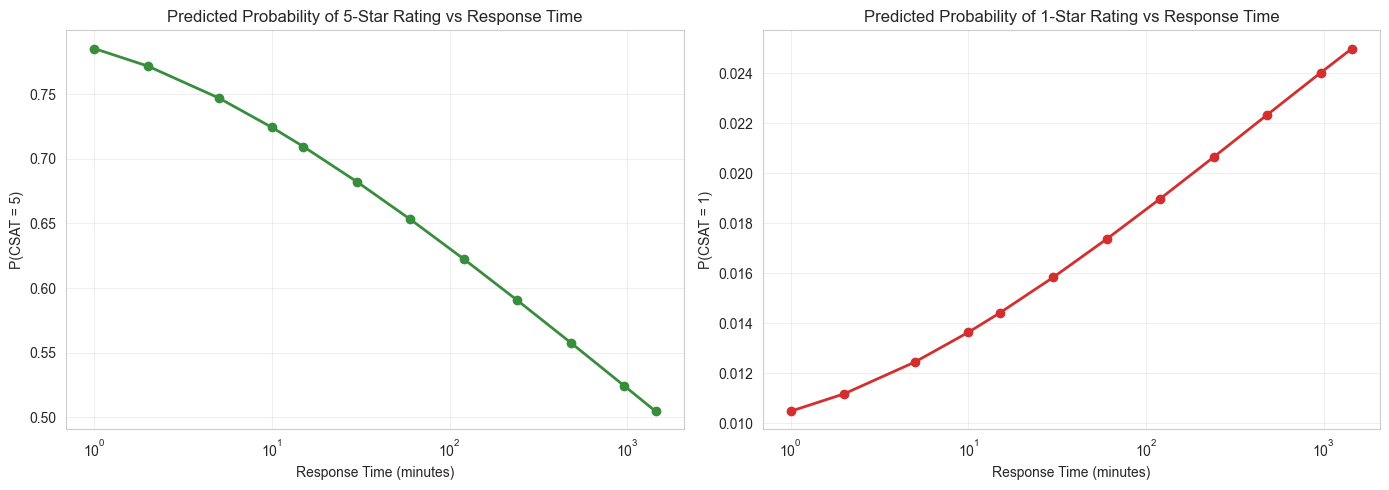

Predicted probabilities at key response times:
  RT (min)  P(CSAT=1)  P(CSAT=5)
         1      0.082      0.785
         2      0.089      0.772
         5      0.100      0.747
        10      0.111      0.724
        15      0.119      0.709
        30      0.133      0.682
        60      0.149      0.653
       120      0.166      0.622
       240      0.186      0.591
       480      0.207      0.558
       960      0.230      0.524
      1440      0.244      0.505


In [48]:
# Create a range of response times for prediction
rt_range = np.array([1, 2, 5, 10, 15, 30, 60, 120, 240, 480, 960, 1440])
log_rt_range = np.log1p(rt_range)

# Use median values for other features
median_features = X_train.median()
pred_df = pd.DataFrame({
    'log_response_time': log_rt_range,
    'channel_name_enc': median_features['channel_name_enc'],
    'category_enc': median_features['category_enc'],
    'Agent Shift_enc': median_features['Agent Shift_enc'],
    'Tenure Bucket_enc': median_features['Tenure Bucket_enc'],
})

# Predict probabilities
probs = ordinal_result.predict(pred_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Probability of CSAT=5 vs response time
axes[0].plot(rt_range, probs[5].values if 5 in probs.columns else probs.iloc[:, -1].values,
             'o-', color='#388e3c', linewidth=2, markersize=6)
axes[0].set_xlabel('Response Time (minutes)')
axes[0].set_ylabel('P(CSAT = 5)')
axes[0].set_title('Predicted Probability of 5-Star Rating vs Response Time')
axes[0].set_xscale('log')
axes[0].grid(True, alpha=0.3)

# Probability of CSAT=1 vs response time
axes[1].plot(rt_range, probs[1].values if 1 in probs.columns else probs.iloc[:, 0].values,
             'o-', color='#d32f2f', linewidth=2, markersize=6)
axes[1].set_xlabel('Response Time (minutes)')
axes[1].set_ylabel('P(CSAT = 1)')
axes[1].set_title('Predicted Probability of 1-Star Rating vs Response Time')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Predicted probabilities at key response times:')
print(f'{"RT (min)":>10} {"P(CSAT=1)":>10} {"P(CSAT=5)":>10}')
for i, rt in enumerate(rt_range):
    p1 = probs.iloc[i, 0]  # First column = score 1
    p5 = probs.iloc[i, -1]  # Last column = score 5
    print(f'{rt:>10} {p1:>10.3f} {p5:>10.3f}')

## 3.4 Confusion Matrix - Full Model

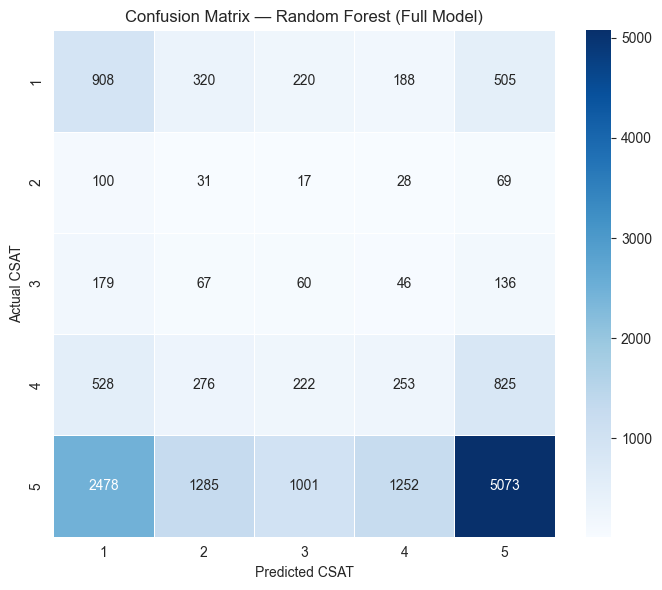

In [49]:
# Confusion matrix for the Random Forest model
cm = confusion_matrix(y_test, y_pred_rf, labels=[1, 2, 3, 4, 5])

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[1,2,3,4,5],
            yticklabels=[1,2,3,4,5], ax=ax, linewidths=0.5)
ax.set_xlabel('Predicted CSAT')
ax.set_ylabel('Actual CSAT')
ax.set_title('Confusion Matrix — Random Forest (Full Model)')
plt.tight_layout()
plt.show()

### Predictive Analytics - Key Findings

1. **Response time is the most important predictor** in the Random Forest model its Gini feature importance is around 52% which the highest percentage as it carries more predictive signal than channel, category, shift, or tenure.
2. **Ordinal Logistic Regression** confirms a significant negative coefficient for log(response_time) with an odds ratio of around 0.82.
3. **The predicted probability of a 5-star rating declines** as response time increases, while the probability of a 1-star rating rises — directly modelling the hypothesis.

# OVERALL CONCLUSION

**Descriptive Analysis**: Mean CSAT drops from 4.51 to 3.82 when the response time increases.

**Inferential Analysis**: All 3 tests demonstrates significant results which supports the alternate hypothesis of prompt responses result in higher customer satisfaction, gaining the customer's sense of reliability.

**Predictive Analysis**: As it can be seen in the Random Forest classifier, the Response time is the top predictor. Ordinal logistic regression shows OR < 1 for the response time which shows slower response times result lower odds of higher CSAT.

**Conclusion:** All three analytical approaches - descriptive, inferential, and predictive - converge to support the hypothesis that **prompt responses from service staff are associated with improved customer perceptions of reliability** (as proxied by CSAT scores). The effect is **statistically significant** but **small in magnitude** (rho ≈ 0.19, around 3–4% variance explained), meaning that while response speed is a genuine and consistent factor, other aspects of service quality such as resolution quality, agent empathy, communication clarity likely contribute more to overall satisfaction.

### Limitations
- **CSAT as proxy:** CSAT captures broader satisfaction, not purely perceived reliability.
- **Observational design:** Association does not means causation. Faster responses may co-occur with other quality indicators.
- **Small effect sizes:** Practically, response speed is one of many drivers of satisfaction.
- **Data quality:** 6.5% of records excluded due to invalid timestamps.